In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings

# Ignora tutti i warning
warnings.filterwarnings('ignore')

# Opzionale: se vuoi silenziare solo i warning futuri (Deprecation)
# warnings.filterwarnings('ignore', category=FutureWarning)


# Setup estetico
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Percorsi specifici per DUKE
# Assicurati che i nomi dei file corrispondano a quelli caricati
FILE_DUKE = 'duke_lesions_radiomic_medsam.csv' 
RAW_PATH_DUKE = Path('/Users/francesco/Tesi/BC-ML4/dataset/original') / FILE_DUKE
OUTPUT_PATH_DUKE = Path('/Users/francesco/Tesi/BC-ML4/dataset/cleaned/TestProva')
OUTPUT_PATH_DUKE.mkdir(parents=True, exist_ok=True)

# Generazione Report

In [2]:
def genera_report_duke(df, dataset_name):
    print(f"\n📊 DISTRIBUZIONE TARGET DUKE: {dataset_name}")
    
    # Colonne target già binarizzate
    targets = ['ER [SII]', 'PR [SII]', 'HER2 [SII]']
    
    # Creiamo una griglia 3x1 (3 righe, 1 colonna)
    fig, axes = plt.subplots(3, 1, figsize=(8, 18))
    
    for i, col in enumerate(targets):
        if col in df.columns:
            # Calcolo dei conteggi per le statistiche
            data = df[col].dropna()
            count_0 = (data == 0).sum()
            count_1 = (data == 1).sum()
            
            # Grafico a barre
            sns.countplot(x=data, ax=axes[i], palette="magma")
            
            axes[i].set_title(f"Distribuzione {col}", fontsize=14, fontweight='bold')
            axes[i].set_xlabel("Valore (0=Neg, 1=Pos)")
            axes[i].set_ylabel("Numero di pazienti")
            
            # Print delle statistiche sotto ogni grafico o in console
            print(f"✅ {col}: Negativi (0) = {count_0}, Positivi (1) = {count_1}")
        else:
            axes[i].text(0.5, 0.5, f"Colonna '{col}' non trovata", 
                         ha='center', va='center', fontsize=12)
            axes[i].set_axis_off()

    plt.tight_layout(pad=4.0)
    plt.show()

# Esecuzione e Plot

✅ Colonna ER copiata in ER [SII]
✅ Colonna PR copiata in PR [SII]
✅ Colonna HER2 copiata in HER2 [SII]

📊 DISTRIBUZIONE TARGET DUKE: Dataset DUKE
✅ ER [SII]: Negativi (0) = 123, Positivi (1) = 168
✅ PR [SII]: Negativi (0) = 157, Positivi (1) = 134
✅ HER2 [SII]: Negativi (0) = 208, Positivi (1) = 83


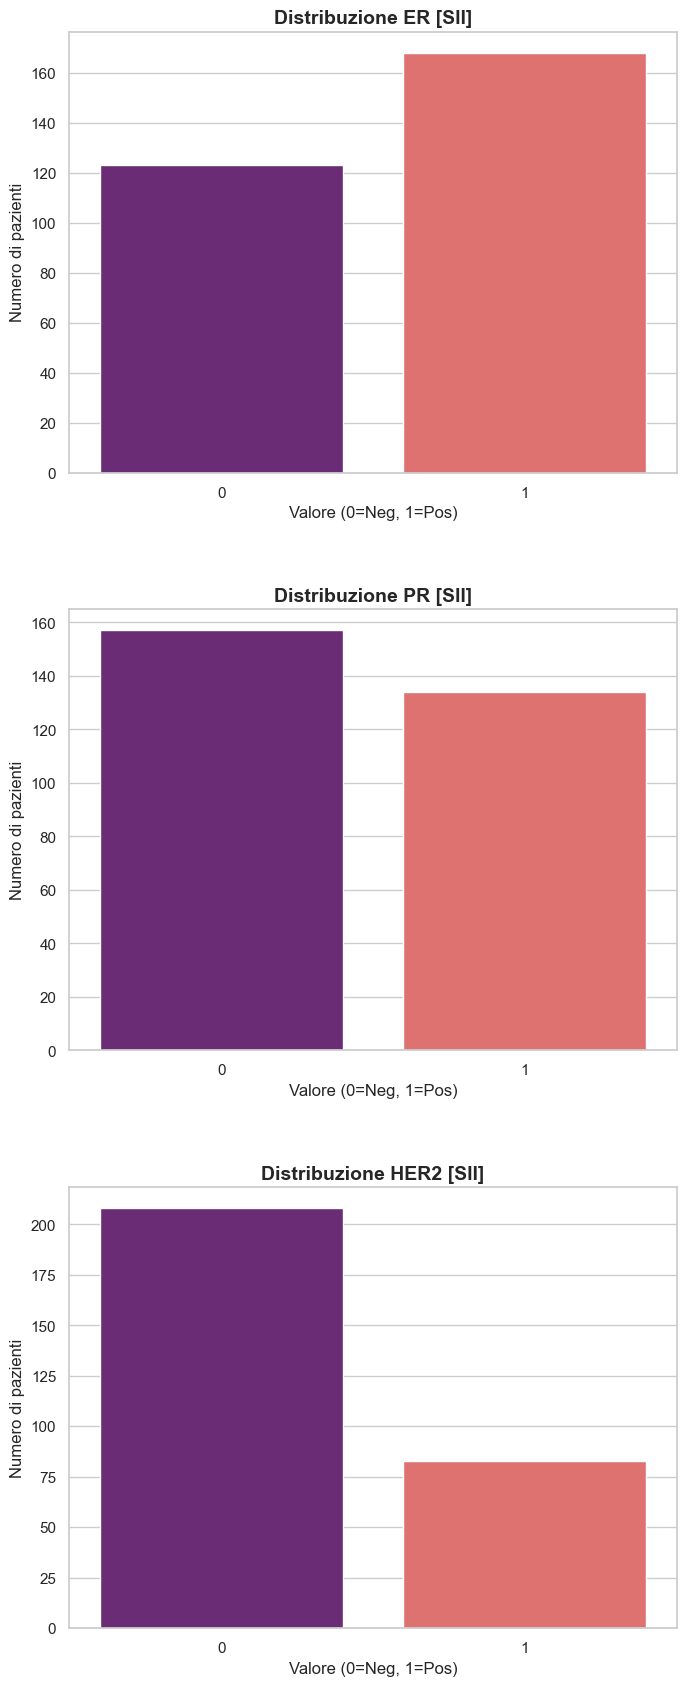

In [3]:
# 1. Caricamento
df_duke_raw = pd.read_csv(RAW_PATH_DUKE)

# 2. Copia dei valori binari nelle colonne standard [SII]
# Dato che Duke è già binario, facciamo una copia diretta
for col in ['ER', 'PR', 'HER2']:
    if col in df_duke_raw.columns:
        # Creiamo la colonna standard [SII] leggendo i valori già binarizzati
        df_duke_raw[f'{col} [SII]'] = df_duke_raw[col]
        print(f"✅ Colonna {col} copiata in {col} [SII]")

# 3. Generazione dei grafici di controllo
# Ora a sinistra e a destra vedrai grafici quasi identici, 
# il che conferma che Duke era già binarizzato correttamente.
genera_report_duke(df_duke_raw, "Dataset DUKE")

# 5. Salvataggio
df_duke_raw.to_csv(OUTPUT_PATH_DUKE / FILE_DUKE, index=False)